In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

In [3]:
df = pd.read_excel('./data/raw_data.xlsx')

In [ ]:
df

,Timestamp,TransactionID,AccountID,Amount,Merchant,TransactionType,Location
0,2023-01-01 08:00:00,TXN1127,ACC4,95071.92,MerchantH,Purchase,Tokyo
1,2023-01-01 08:01:00,TXN1639,ACC10,15607.89,MerchantH,Purchase,London
2,2023-01-01 08:02:00,TXN872,ACC8,65092.34,MerchantE,Withdrawal,London
3,2023-01-01 08:03:00,TXN1438,ACC6,87.87,MerchantE,Purchase,London
4,2023-01-01 08:04:00,TXN1338,ACC6,716.56,MerchantI,Purchase,Los Angeles
...,...,...,...,...,...,...,...
216955,31-05-2023 23:55,TXN1286,ACC6,62536.88,MerchantA,Withdrawal,San Francisco
216956,31-05-2023 23:56,TXN1015,ACC5,68629.69,MerchantG,Transfer,London
216957,31-05-2023 23:57,TXN1979,ACC15,8203.57,MerchantF,Purchase,London
216958,31-05-2023 23:58,TXN1845,ACC14,77800.36,MerchantF,Purchase,New York


In [ ]:
df.shape

(216960, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216960 entries, 0 to 216959
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Timestamp        216960 non-null  object 
 1   TransactionID    216960 non-null  object 
 2   AccountID        216960 non-null  object 
 3   Amount           216960 non-null  float64
 4   Merchant         216960 non-null  object 
 5   TransactionType  216960 non-null  object 
 6   Location         216960 non-null  object 
dtypes: float64(1), object(6)
memory usage: 11.6+ MB


In [ ]:
print(df.isnull().sum())

Timestamp          0
TransactionID      0
AccountID          0
Amount             0
Merchant           0
TransactionType    0
Location           0
dtype: int64


In [ ]:
df.describe()

,Amount
count,216960.000000
mean,50090.025108
std,29097.905016
min,10.510000
25%,25061.242500
50%,50183.980000
75%,75080.460000
max,978942.260000


In [ ]:
df.columns = df.columns.str.lower()

In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
#df['day'] = df['date'].dt.day
df['day_of_week'] = df['timestamp'].dt.day_name()

In [ ]:
for col in df.columns:
  print(f"Column: {col}")
  print(df[col].nunique())

Column: timestamp
216960
Column: transactionid
1999
Column: accountid
15
Column: amount
214687
Column: merchant
10
Column: transactiontype
3
Column: location
5
Column: year
1
Column: month
12
Column: day_of_week
7


In [ ]:
categorical_cols = ['location', 'transactiontype', 'merchant', 'accountid']
if categorical_cols:
    print("Categorical Colummns")
    for col in categorical_cols:
        print(f"\nColumn: {col}")
        print(df[col].unique())

Categorical Colummns

Column: location
['Tokyo' 'London' 'Los Angeles' 'San Francisco' 'New York']

Column: transactiontype
['Purchase' 'Withdrawal' 'Transfer']

Column: merchant
['MerchantH' 'MerchantE' 'MerchantI' 'MerchantC' 'MerchantD' 'MerchantB'
 'MerchantJ' 'MerchantA' 'MerchantG' 'MerchantF']

Column: accountid
['ACC4' 'ACC10' 'ACC8' 'ACC6' 'ACC15' 'ACC9' 'ACC7' 'ACC12' 'ACC2' 'ACC14'
 'ACC1' 'ACC11' 'ACC3' 'ACC5' 'ACC13']


In [ ]:
def target_encode(df, target_col, cat_cols):
    df_encoded = df.copy()
    for col in cat_cols:
        mean_map = df_encoded.groupby(col)[target_col].mean()
        df_encoded[f"{col}"] = df_encoded[col].map(mean_map)
    return df_encoded

cat_cols = ['merchant', 'location', 'transactiontype']
df = target_encode(df, 'amount', cat_cols)

In [ ]:
df

,timestamp,transactionid,accountid,amount,merchant,transactiontype,location,year,month,day_of_week
0,2023-01-01 08:00:00,TXN1127,ACC4,95071.92,50260.357883,50208.496692,50188.353242,2023,1,Sunday
1,2023-01-01 08:01:00,TXN1639,ACC10,15607.89,50260.357883,50208.496692,50071.058024,2023,1,Sunday
2,2023-01-01 08:02:00,TXN872,ACC8,65092.34,50096.280693,50022.173112,50071.058024,2023,1,Sunday
3,2023-01-01 08:03:00,TXN1438,ACC6,87.87,50096.280693,50208.496692,50071.058024,2023,1,Sunday
4,2023-01-01 08:04:00,TXN1338,ACC6,716.56,50455.825346,50208.496692,49970.069477,2023,1,Sunday
...,...,...,...,...,...,...,...,...,...,...
216955,2023-05-31 23:55:00,TXN1286,ACC6,62536.88,50057.360128,50022.173112,50142.573623,2023,5,Wednesday
216956,2023-05-31 23:56:00,TXN1015,ACC5,68629.69,49784.497070,50039.511113,50071.058024,2023,5,Wednesday
216957,2023-05-31 23:57:00,TXN1979,ACC15,8203.57,50100.565369,50208.496692,50071.058024,2023,5,Wednesday
216958,2023-05-31 23:58:00,TXN1845,ACC14,77800.36,50100.565369,50208.496692,50077.849485,2023,5,Wednesday


In [ ]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap='RdBu', vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

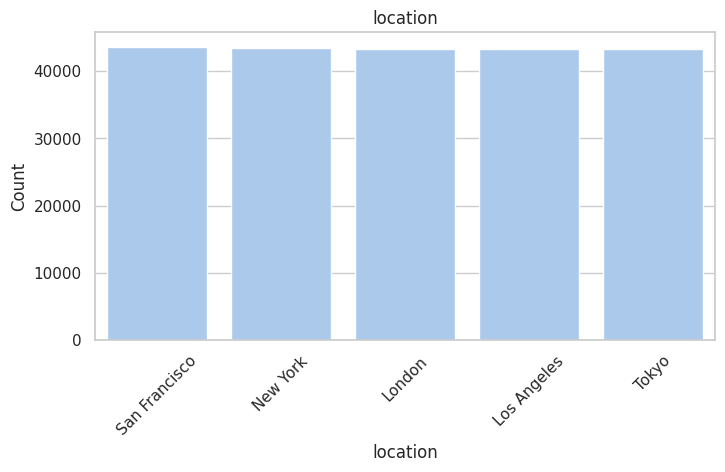

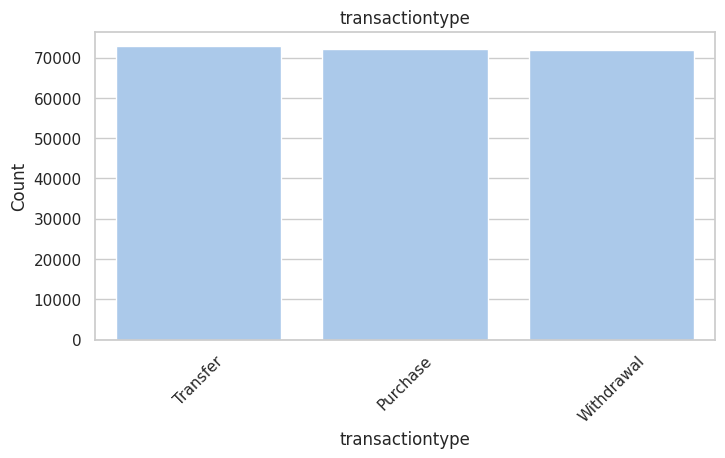

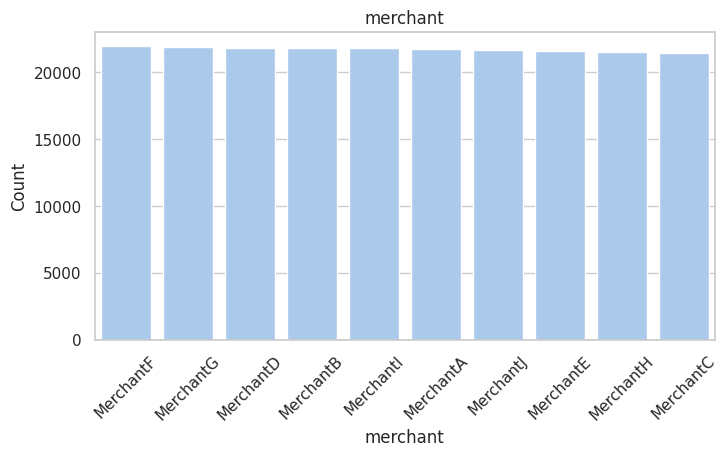

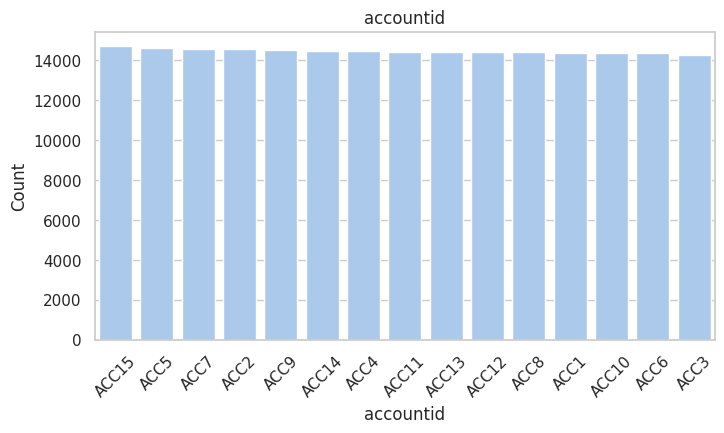

In [ ]:
sns.set(style="whitegrid", palette="pastel")
plt.rcParams['figure.figsize'] = (8, 5)

categorical_cols = ['location', 'transactiontype', 'merchant', 'accountid']
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'{col}')
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

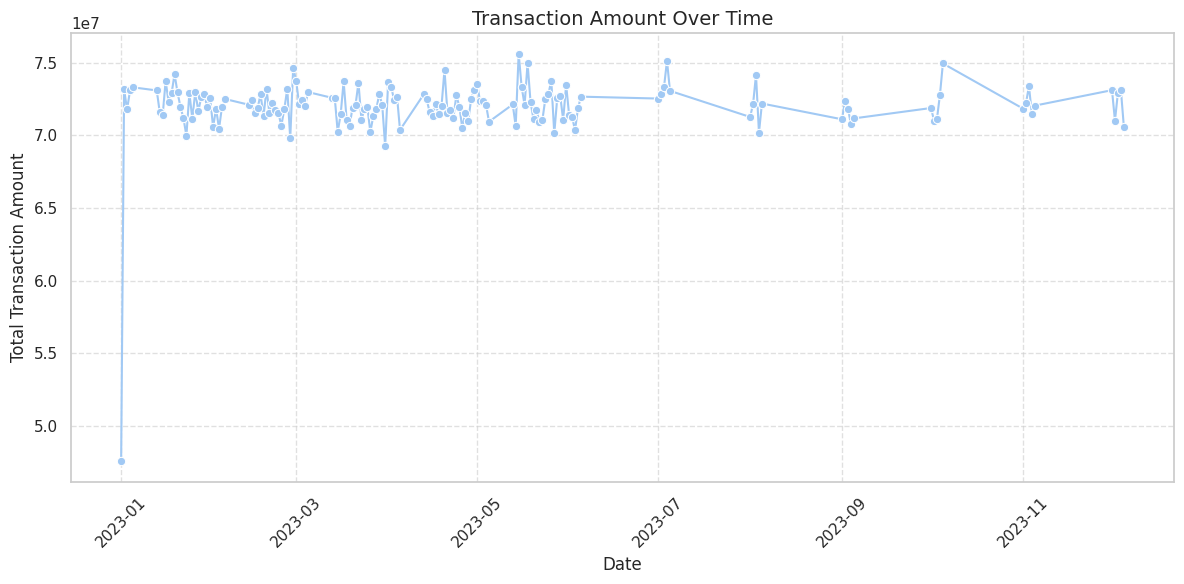

In [ ]:
# Aggregate total amount per day

daily_amount = df.groupby(df['timestamp'].dt.date)['amount'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=daily_amount, x='timestamp', y='amount', marker='o')

plt.title("Transaction Amount Over Time", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Total Transaction Amount")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
sns.set(style="whitegrid", palette="pastel")
plt.rcParams['figure.figsize'] = (8, 5)

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

for cat in categorical_cols:
    if 'amount' in df.columns:
        plt.figure(figsize=(8, 4))
        sns.boxplot(data=df, x=cat, y='amount')
        plt.title(f"Distribution of Amount by {cat}", fontsize=13)
        plt.xticks(rotation=45)
        plt.xlabel(cat)
        plt.ylabel("Transaction Amount")
        plt.show()

In [ ]:
df = df.drop(columns=['timestamp'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216960 entries, 0 to 216959
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   transactionid    216960 non-null  object 
 1   accountid        216960 non-null  object 
 2   amount           216960 non-null  float64
 3   merchant         216960 non-null  float64
 4   transactiontype  216960 non-null  float64
 5   location         216960 non-null  float64
 6   year             216960 non-null  int32  
 7   month            216960 non-null  int32  
 8   day_of_week      216960 non-null  object 
dtypes: float64(4), int32(2), object(3)
memory usage: 13.2+ MB


In [ ]:
df = df.drop(columns=['transactionid', 'accountid'])

In [ ]:
def target_encode(df, target_col, cat_cols):
    df_encoded = df.copy()
    for col in cat_cols:
        mean_map = df_encoded.groupby(col)[target_col].mean()
        df_encoded[f"{col}_te"] = df_encoded[col].map(mean_map)
    return df_encoded

cat_cols = ['merchant', 'location', 'transactiontype']
df = target_encode(df, 'amount', cat_cols)

'''le = LabelEncoder()
for col in cat_cols:
    df[f"{col}_le"] = le.fit_transform(df[col])'''

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df = df.select_dtypes(include=['int64', 'float64'])

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)


In [ ]:
print("Final Isolation Forest dataset shape:", scaled_data.shape)

Final Isolation Forest dataset shape: (216960, 4)


In [ ]:
results = []
anomaly_results = {}
all_runs_scores = {}
all_runs_predictions = {}

In [ ]:
contamination_grid = [0.1, 0.08, 0.02, 0.05]

In [ ]:
X_train, X_test = train_test_split(scaled_data, test_size=0.3, random_state=42)

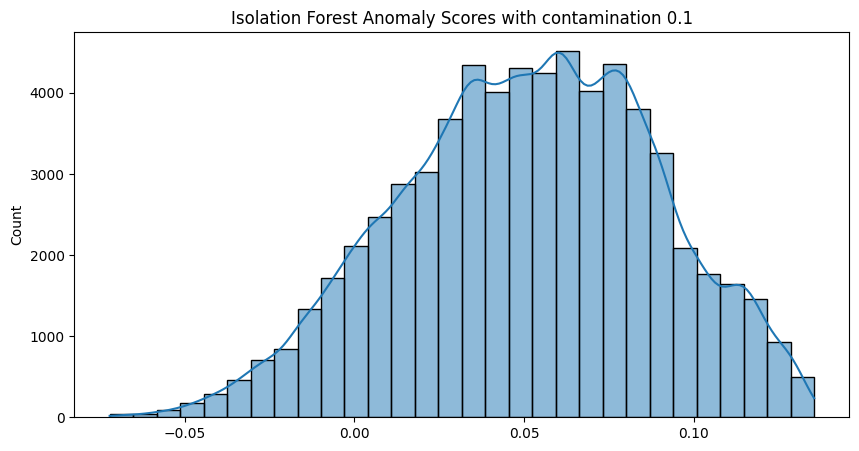

          0         1         2         3  anomaly_score
0  1.704494  1.683546 -1.623416  1.410424      -0.072110
1  1.678517  1.683546 -1.623416  1.410424      -0.072110
2  1.706729  1.683546 -1.623416  1.410424      -0.072110
3  1.679315  1.683546 -1.623416  1.410424      -0.072110
4  1.695155  1.683546 -1.623416  1.410424      -0.071884
5  1.700277  1.683546 -1.623416  1.410424      -0.071884
6  1.689948  1.683546 -1.623416  1.410424      -0.071884
7 -1.720488  1.683546 -1.623416  1.410424      -0.070990
8  1.672036  1.683546 -1.623416  1.410424      -0.070980
9 -1.701544  1.683546 -1.623416  1.410424      -0.070764


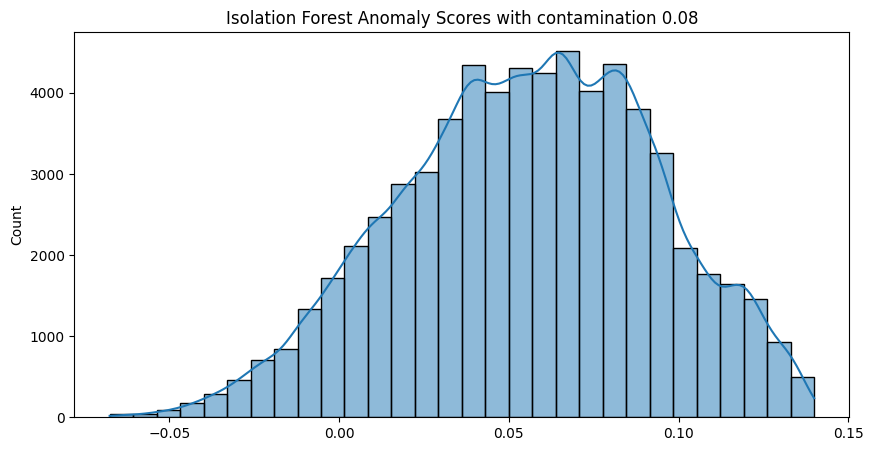

          0         1         2         3  anomaly_score
0  1.704494  1.683546 -1.623416  1.410424      -0.067618
1  1.678517  1.683546 -1.623416  1.410424      -0.067618
2  1.706729  1.683546 -1.623416  1.410424      -0.067618
3  1.679315  1.683546 -1.623416  1.410424      -0.067618
4  1.695155  1.683546 -1.623416  1.410424      -0.067392
5  1.700277  1.683546 -1.623416  1.410424      -0.067392
6  1.689948  1.683546 -1.623416  1.410424      -0.067392
7 -1.720488  1.683546 -1.623416  1.410424      -0.066498
8  1.672036  1.683546 -1.623416  1.410424      -0.066488
9 -1.701544  1.683546 -1.623416  1.410424      -0.066273


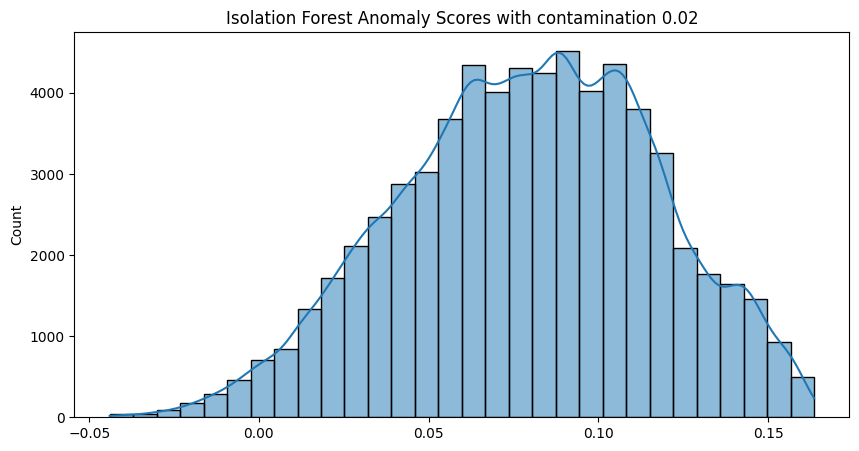

          0         1         2         3  anomaly_score
0  1.704494  1.683546 -1.623416  1.410424      -0.043990
1  1.678517  1.683546 -1.623416  1.410424      -0.043990
2  1.706729  1.683546 -1.623416  1.410424      -0.043990
3  1.679315  1.683546 -1.623416  1.410424      -0.043990
4  1.695155  1.683546 -1.623416  1.410424      -0.043764
5  1.700277  1.683546 -1.623416  1.410424      -0.043764
6  1.689948  1.683546 -1.623416  1.410424      -0.043764
7 -1.720488  1.683546 -1.623416  1.410424      -0.042871
8  1.672036  1.683546 -1.623416  1.410424      -0.042860
9 -1.701544  1.683546 -1.623416  1.410424      -0.042645


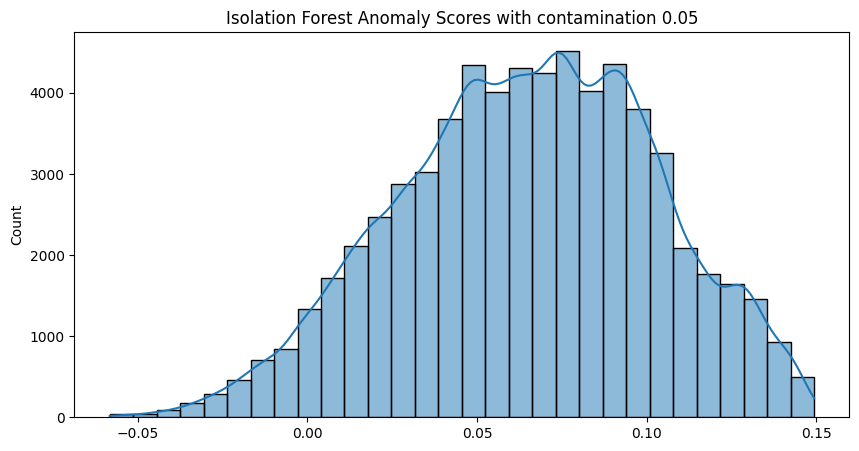

          0         1         2         3  anomaly_score
0  1.704494  1.683546 -1.623416  1.410424      -0.058252
1  1.678517  1.683546 -1.623416  1.410424      -0.058252
2  1.706729  1.683546 -1.623416  1.410424      -0.058252
3  1.679315  1.683546 -1.623416  1.410424      -0.058252
4  1.695155  1.683546 -1.623416  1.410424      -0.058026
5  1.700277  1.683546 -1.623416  1.410424      -0.058026
6  1.689948  1.683546 -1.623416  1.410424      -0.058026
7 -1.720488  1.683546 -1.623416  1.410424      -0.057133
8  1.672036  1.683546 -1.623416  1.410424      -0.057123
9 -1.701544  1.683546 -1.623416  1.410424      -0.056907

Results:
   contamination  Anomalies      Mean       Min       Max
0           0.10       6504  0.051095 -0.072110  0.135475
1           0.08       5197  0.055587 -0.067618  0.139966
2           0.02       1283  0.079215 -0.043990  0.163594
3           0.05       3197  0.064953 -0.058252  0.149332


In [ ]:
for c in contamination_grid:
  iso = IsolationForest(
    n_estimators=200,
    contamination=c,
    max_samples='auto',
    random_state=42
    )
  iso.fit(X_train)
  iso_scores = iso.decision_function(X_test)
  iso_pred = iso.predict(X_test)
  iso_anomalies = np.where(iso_pred == -1, 1, 0)

  all_runs_scores[c] = iso_scores
  all_runs_predictions[c] = iso_anomalies

  plt.figure(figsize=(10,5))
  sns.histplot(iso_scores, bins=30, kde=True)
  plt.title(f"Isolation Forest Anomaly Scores with contamination {c}")
  plt.show()

  top_idx = np.argsort(iso_scores)[:10]

  top_rows = pd.DataFrame(X_test[top_idx]).copy()
  top_rows["anomaly_score"] = iso_scores[top_idx]

  anomaly_results[c] = top_rows

  print(top_rows)

  results.append({
        "contamination": c,
        "Anomalies": iso_anomalies.sum(),
        "Mean": iso_scores.mean(),
        "Min": iso_scores.min(),
        "Max": iso_scores.max()
  })

results_df = pd.DataFrame(results)
print("\nResults:")
print(results_df)

In [ ]:
anomaly_df = pd.DataFrame(X_test, columns=df.columns)
anomaly_df["IF_Anomaly"] = iso_anomalies

print("\nTop anomalies (by GMM & IF):")
display(anomaly_df[(anomaly_df["IF_Anomaly"] == 1)].head(10))


Top anomalies (by GMM & IF):


,amount,merchant_te,location_te,transactiontype_te,merchant_le,location_le,transactiontype_le,IF_Anomaly
3,1.514112,-0.150336,-1.623416,1.410424,-1.567938,-0.708030,-1.225041,1
5,1.418624,1.211045,1.330721,1.410424,1.566788,1.414357,-1.225041,1
21,-1.074070,1.683546,-1.623416,1.410424,1.218485,-0.708030,-1.225041,1
30,1.576378,-1.134438,1.330721,1.410424,-0.871332,1.414357,-1.225041,1
59,-1.291482,1.683546,1.330721,-0.807789,1.218485,1.414357,1.228467,1
76,1.645583,-0.150336,-0.256690,1.410424,-1.567938,-1.415492,-1.225041,1
107,-1.390792,1.683546,-1.623416,-0.807789,1.218485,-0.708030,1.228467,1
124,1.640919,0.783933,1.330721,1.410424,0.870183,1.414357,-1.225041,1
147,-1.466158,0.254389,-0.256690,1.410424,-1.219635,-1.415492,-1.225041,1
153,0.837048,1.683546,-0.256690,1.410424,1.218485,-1.415492,-1.225041,1


In [ ]:
X_test_original = scaler.inverse_transform(X_test)

anomaly_df_original = pd.DataFrame(X_test_original, columns=df.columns)

anomaly_df_original["IF_Anomaly"] = iso_anomalies

print("\nTop anomalies (original values):")
display(anomaly_df_original[anomaly_df_original["IF_Anomaly"] == 1].head(10))


Top anomalies (original values):


,amount,merchant_te,location_te,transactiontype_te,merchant_le,location_le,transactiontype_le,IF_Anomaly
3,94147.41,50057.360128,49970.069477,50208.496692,0.0,1.0,0.0,1
5,91368.92,50353.160668,50188.353242,50208.496692,9.0,4.0,0.0,1
21,18836.91,50455.825346,49970.069477,50208.496692,8.0,1.0,0.0,1
30,95959.21,49843.534709,50188.353242,50208.496692,2.0,4.0,0.0,1
59,12510.68,50455.825346,50188.353242,50022.173112,8.0,4.0,2.0,1
76,97972.93,50057.360128,50071.058024,50208.496692,0.0,0.0,0.0,1
107,9620.98,50455.825346,49970.069477,50022.173112,8.0,1.0,2.0,1
124,97837.21,50260.357883,50188.353242,50208.496692,7.0,4.0,0.0,1
147,7427.99,50145.298716,50071.058024,50208.496692,1.0,0.0,0.0,1
153,74446.32,50455.825346,50071.058024,50208.496692,8.0,0.0,0.0,1


In [ ]:
anomaly_scores = iso.score_samples(X_test)
anomaly_df_original["IF_score"] = anomaly_scores

ranked_anomalies = (
    anomaly_df_original[anomaly_df_original["IF_Anomaly"] == 1]
    .sort_values(by="IF_score")
)

display(ranked_anomalies.head(10))

,amount,merchant_te,location_te,transactiontype_te,merchant_le,location_le,transactiontype_le,IF_Anomaly,IF_score
29813,99765.47,50455.825346,50071.058024,50208.496692,8.0,0.0,0.0,1,-0.627823
50016,99652.33,50455.825346,50071.058024,50208.496692,8.0,0.0,0.0,1,-0.627610
46994,99482.18,50455.825346,50071.058024,50208.496692,8.0,0.0,0.0,1,-0.626126
28762,99248.55,50455.825346,50071.058024,50208.496692,8.0,0.0,0.0,1,-0.626126
23774,99405.06,50455.825346,50071.058024,50208.496692,8.0,0.0,0.0,1,-0.626126
18717,99305.29,50455.825346,50071.058024,50208.496692,8.0,0.0,0.0,1,-0.626126
58923,99752.15,50455.825346,49970.069477,50208.496692,8.0,1.0,0.0,1,-0.625100
10092,99687.11,50455.825346,49970.069477,50208.496692,8.0,1.0,0.0,1,-0.625100
1603,99904.21,50353.160668,50188.353242,50208.496692,9.0,4.0,0.0,1,-0.624799
9809,99611.93,50353.160668,50188.353242,50208.496692,9.0,4.0,0.0,1,-0.624799


In [ ]:
anomaly = pd.DataFrame(ranked_anomalies)
anomaly.to_csv("anomaly.csv")

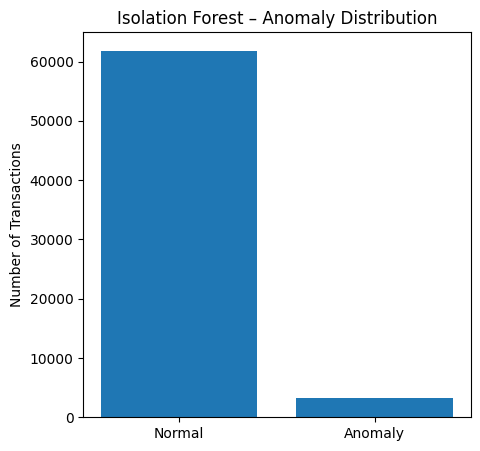

In [ ]:
counts = anomaly_df_original["IF_Anomaly"].value_counts()

plt.figure(figsize=(5, 5))
plt.bar(["Normal", "Anomaly"], counts)
plt.title("Isolation Forest – Anomaly Distribution")
plt.ylabel("Number of Transactions")
plt.show()

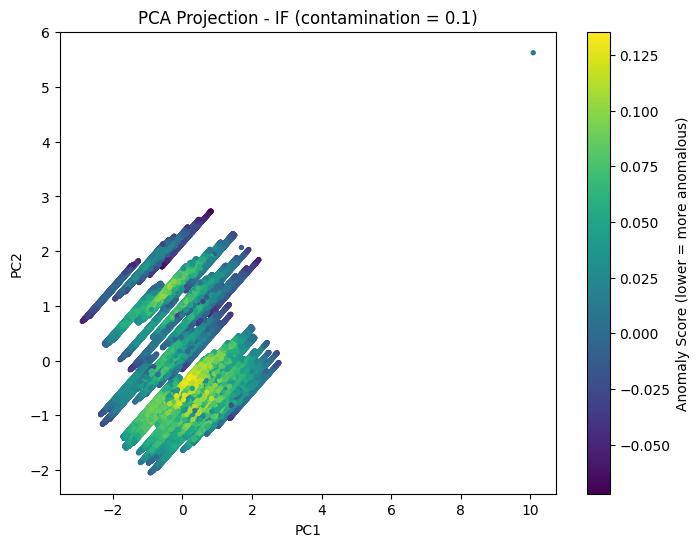

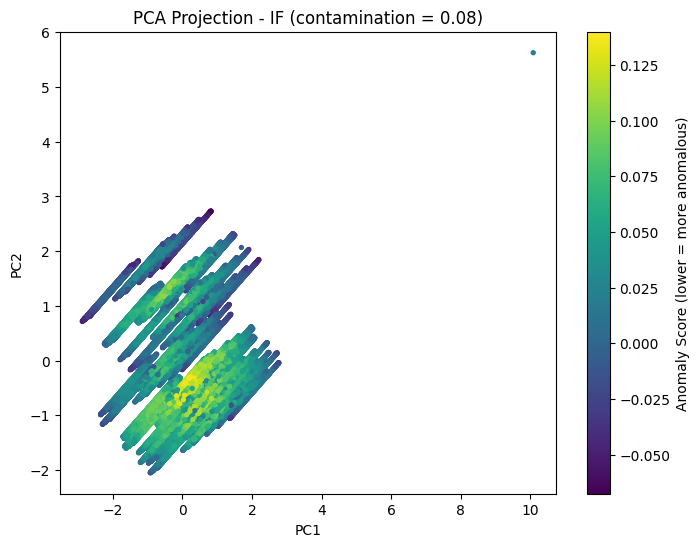

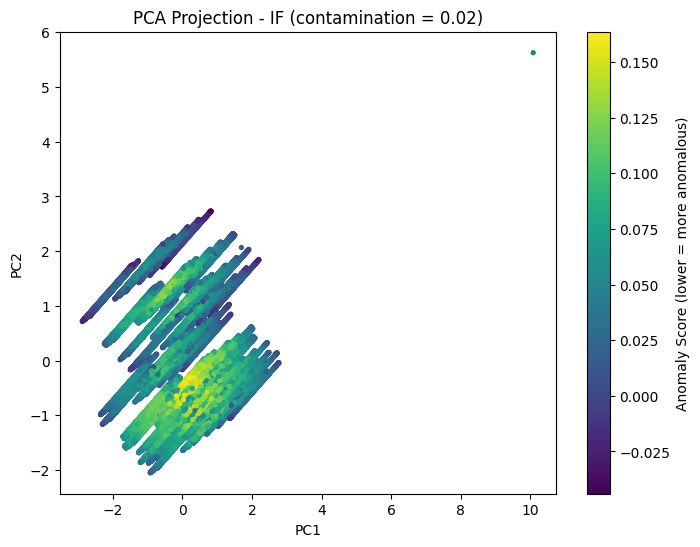

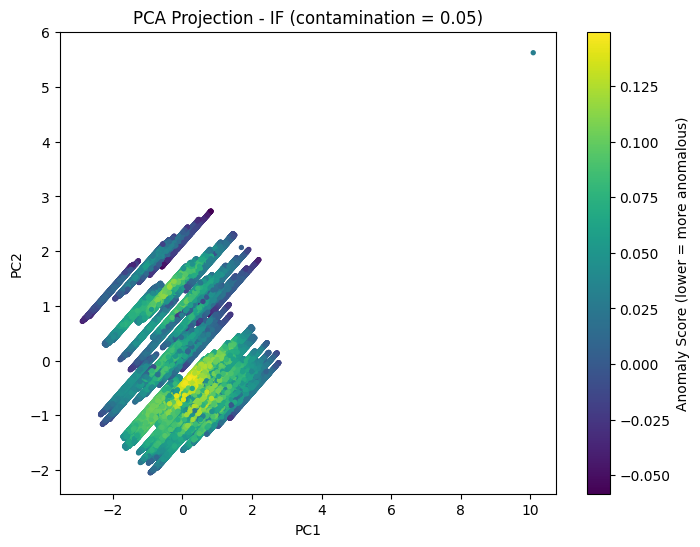

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Convert X_test to DataFrame if it is a numpy array
X_test_df = pd.DataFrame(X_test, columns=df.columns)

# Fit PCA once
pca = PCA(n_components=2)
pca_test = pca.fit_transform(X_test_df)

# Loop through each contamination setting
for c in contamination_grid:

    scores = all_runs_scores[c]   # anomaly scores for this contamination

    plt.figure(figsize=(8,6))
    plt.scatter(
        pca_test[:, 0],
        pca_test[:, 1],
        c=scores,
        s=8,
        cmap='viridis'
    )
    plt.colorbar(label="Anomaly Score (lower = more anomalous)")
    plt.title(f"PCA Projection - IF (contamination = {c})")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()


In [ ]:
from sklearn.inspection import permutation_importance

for c in contamination_grid:
  iso = IsolationForest(
    n_estimators=200,
    contamination=c,
    max_samples='auto',
    random_state=42
    )


  iso.fit(X_train)
  iso_scores = iso.decision_function(X_test)
  iso_pred = iso.predict(X_test)
  iso_anomalies = np.where(iso_pred == -1, 1, 0)

  result = permutation_importance(
    iso,
    X_test,
    iso.score_samples(X_test),
    n_repeats=10,
    random_state=42
    )

  importances = pd.Series(result.importances_mean, index=df.columns)
  print(importances.sort_values(ascending=False))



